## Practical Work (TD #2): Support Vector Machines on the Penguins Dataset

1. Apply Support Vector Machines (SVM) to classify penguin species based on body measurements.
2. Explore: 
    - preprocessing
    - visualization
    - model training
    - evaluation 
    - hyperparameter tuning.

### 🧠 Dataset
* We’ll use Seaborn’s penguins dataset, which contains data about three penguin species:
    - Adelie
    - Chinstrap
    - Gentoo
* Each sample includes physical characteristics like bill length, flipper length, and body mass.

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(url)
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


## ⚙️ Step 1 — Load and Explore the Dataset

**Import libraries:**

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn tools for SVM
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [3]:

# Dropping rows with missing values (essential for SVM)
penguins_clean = penguins.dropna()

# Encoding the target (species) into integers
le = LabelEncoder()
penguins_clean['species_encoded'] = le.fit_transform(penguins_clean['species'])

# Quick look at the cleaned data
print(f"Shape after cleaning: {penguins_clean.shape}")
print(penguins_clean.head())

Shape after cleaning: (333, 8)
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  species_encoded  
0       3750.0    MALE                0  
1       3800.0  FEMALE                0  
2       3250.0  FEMALE                0  
4       3450.0  FEMALE                0  
5       3650.0    MALE                0  


C:\Users\aurel\AppData\Local\Temp\ipykernel_27104\547727291.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  penguins_clean['species_encoded'] = le.fit_transform(penguins_clean['species'])


### Step 2 — Encode and Visualize the Data

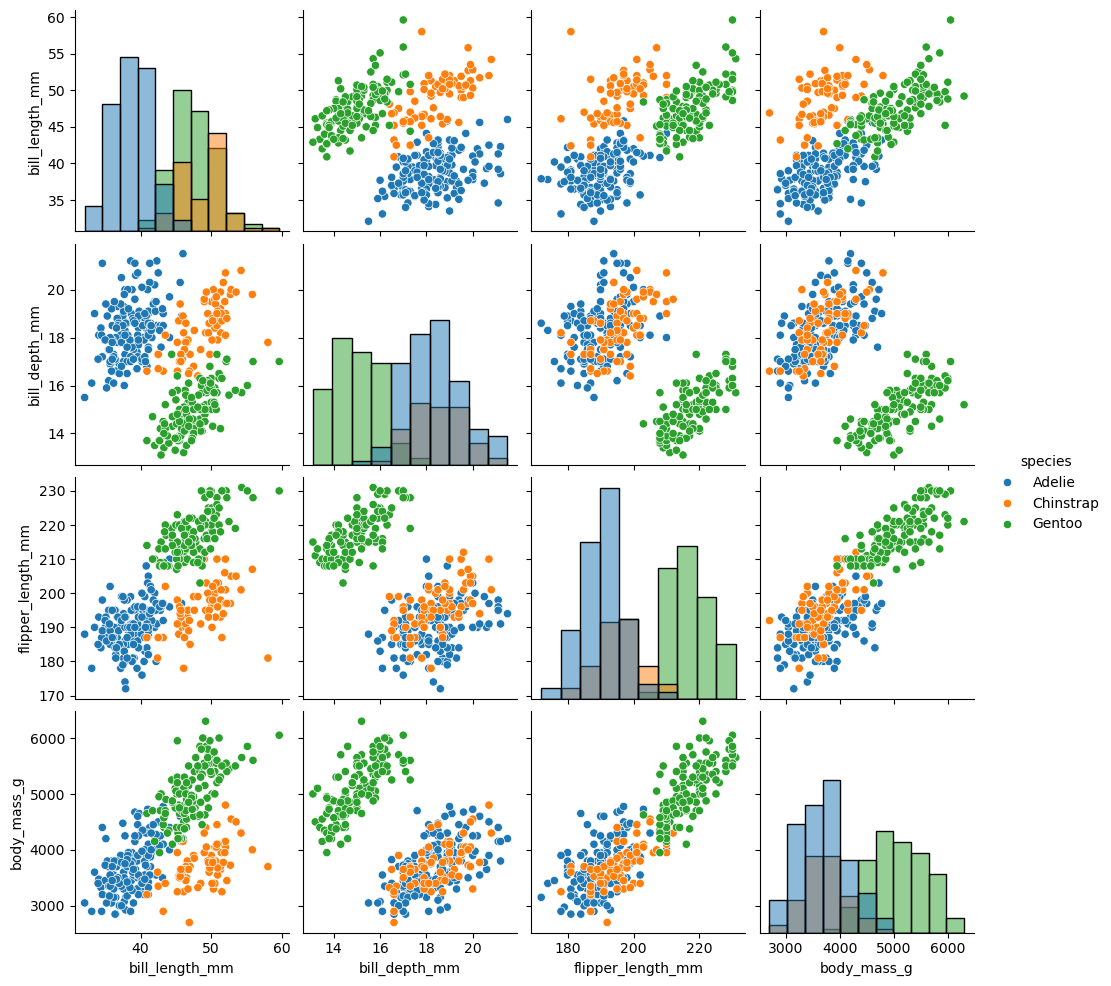

In [4]:
sns.pairplot(penguins, hue='species', diag_kind='hist')
plt.show()


Question:

**Q1**: Do you observe overlap between species?

**Q2**:Which features seem most discriminative?

### 🧩 Step 3 — Split and Standardize

In [5]:
# numerical features
X = penguins_clean[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = penguins_clean['species']

# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardization (Scaling)
scaler = StandardScaler()

# Fit on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same parameters
X_test_scaled = scaler.transform(X_test)

print("Standardization complete.")
print(f"Mean of scaled features: {np.round(X_train_scaled.mean(), 2)}")
print(f"Std of scaled features: {X_train_scaled.std()}")

Standardization complete.
Mean of scaled features: -0.0
Std of scaled features: 0.9999999999999999


### 🔹 Step 4 — Train a Linear SVM

In [8]:
# Initialize the SVM with a linear kernel
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

# Train the model
svm_linear.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = svm_linear.predict(X_test_scaled)

# Quick evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 1.0000


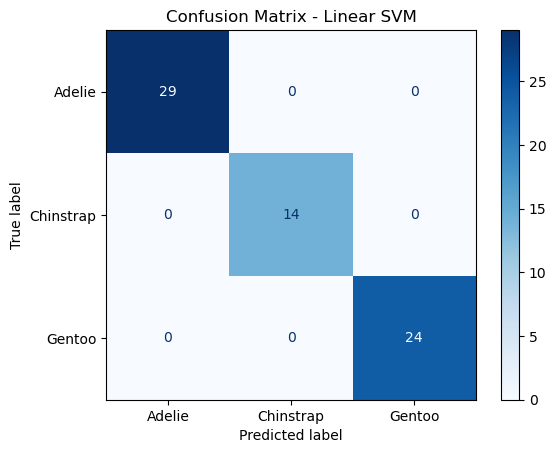

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_linear.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Linear SVM")
plt.show()